
# Q-Learning: Patojo en un Laberinto 🦜🏁

## Introducción
Este notebook demuestra cómo un agente (ratón) puede aprender a salir de un laberinto utilizando el algoritmo de Q-Learning.

---

### 📦 Configuración del entorno


In [ ]:

import random
import matplotlib.pyplot as plt

# Definición del laberinto
grid_rows_size = 6+1
grid_cols_size = 5+1
states = [
    (i, j)
    for i in range(grid_rows_size)
    for j in range(grid_cols_size)
]

actions = ['up', 'down', 'left', 'right']

rewards = {
    (4, 1): +10, (0, 2): +10, (2, 2): +10, (1, 5): +10,
    (3, 0): -10, (1, 1): -10, (3, 3): -10, (1, 4): -10,
    (4, 4): +50
}

Q = {s: {a: 0 for a in actions} for s in states}

def next_state(state, action):
    i, j = state
    return {
        'up': (max(0, i - 1), j),
        'down': (min(grid_rows_size - 1, i + 1), j),
        'left': (i, max(0, j - 1)),
        'right': (i, min(grid_cols_size - 1, j + 1))
    }[action]


print(f'{grid_cols_size=}')
print(f'{grid_rows_size=}')
print(f'{states=}')
print(f'{actions=}')
print(f'{rewards=}')
print(f'{Q=}')

grid_cols_size=6
grid_rows_size=7
states=[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5)]
actions=['up', 'down', 'left', 'right']
rewards={(4, 1): 10, (0, 2): 10, (2, 2): 10, (1, 5): 10, (3, 0): -10, (1, 1): -10, (3, 3): -10, (1, 4): -10, (4, 4): 50}
Q={(0, 0): {'up': 0, 'down': 0, 'left': 0, 'right': 0}, (0, 1): {'up': 0, 'down': 0, 'left': 0, 'right': 0}, (0, 2): {'up': 0, 'down': 0, 'left': 0, 'right': 0}, (0, 3): {'up': 0, 'down': 0, 'left': 0, 'right': 0}, (0, 4): {'up': 0, 'down': 0, 'left': 0, 'right': 0}, (0, 5): {'up': 0, 'down': 0, 'left': 0, 'right': 0}, (1, 0): {'up': 0, 'down': 0, 'left': 0, 'right': 0}, (1, 1): {'up': 0, 'down': 0, 'left': 0, 'right': 0}, (1, 2): {'up': 0, 'down': 0, 'left

### ⚙️ Entrenamiento con Q-Learning

In [12]:

alpha, gamma, epsilon = 0.1, 0.9, 0.2
episodes = 500
rewards_per_episode = []

for episode in range(episodes):
    state = random.choice(states)
    total_reward = 0
    while state != (4, 4):
        action = random.choice(actions)\
            if random.uniform(0, 1) < epsilon\
            else max(Q[state], key=Q[state].get)

        next_s = next_state(state, action)
        reward = rewards.get(next_s, -1)
        old_q = Q[state][action]
        future_q = max(Q[next_s].values())

        Q[state][action] = old_q + alpha * (reward + gamma * future_q - old_q)

        state = next_s
        total_reward += reward
    rewards_per_episode.append(total_reward)


### 📊 Recompensa acumulada por episodio

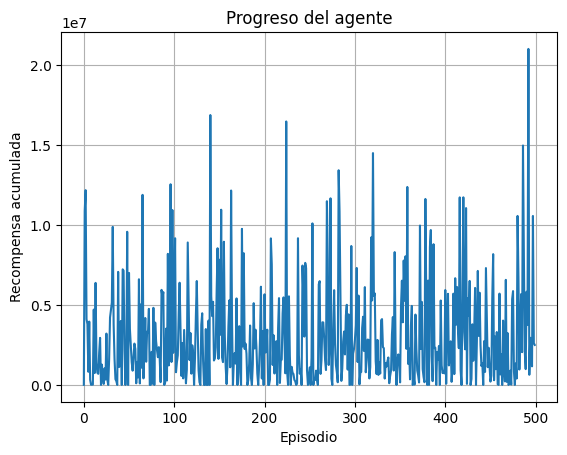

In [13]:

plt.plot(rewards_per_episode)
plt.xlabel('Episodio')
plt.ylabel('Recompensa acumulada')
plt.title('Progreso del agente')
plt.grid(True)
plt.show()


### 🔍 Política aprendida (acciones con mejor Q por estado)

In [14]:

for i in range(grid_rows_size):
    for j in range(grid_cols_size):
        s = (i, j)
        best_action = max(Q[s], key=Q[s].get)
        print(f"Estado {s}: {best_action}")


Estado (0, 0): right
Estado (0, 1): right
Estado (0, 2): up
Estado (0, 3): left
Estado (0, 4): left
Estado (0, 5): down
Estado (1, 0): up
Estado (1, 1): up
Estado (1, 2): up
Estado (1, 3): up
Estado (1, 4): right
Estado (1, 5): right
Estado (2, 0): right
Estado (2, 1): right
Estado (2, 2): up
Estado (2, 3): left
Estado (2, 4): right
Estado (2, 5): up
Estado (3, 0): right
Estado (3, 1): up
Estado (3, 2): up
Estado (3, 3): left
Estado (3, 4): up
Estado (3, 5): up
Estado (4, 0): right
Estado (4, 1): right
Estado (4, 2): up
Estado (4, 3): left
Estado (4, 4): up
Estado (4, 5): up
Estado (5, 0): right
Estado (5, 1): up
Estado (5, 2): left
Estado (5, 3): left
Estado (5, 4): up
Estado (5, 5): up
Estado (6, 0): right
Estado (6, 1): up
Estado (6, 2): up
Estado (6, 3): left
Estado (6, 4): up
Estado (6, 5): left
